In [3]:
import os

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import numpy as np
import pandas as pd
import cv2

import torch
import torchvision.transforms as transforms
import torch.utils
from torchvision.utils import draw_segmentation_masks, draw_bounding_boxes
from torchvision.ops import masks_to_boxes
from torchvision.models.segmentation import (
    deeplabv3_resnet50,
    DeepLabV3_ResNet50_Weights,
)
from torchvision.io import read_file, decode_image
from torchvision.ops import masks_to_boxes

import torchvision.transforms.functional as F

from torchvision.transforms.functional import to_pil_image

In [4]:
# load the pretrained DeepLabV3 model (ResNet50 backbone)
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights)
model.eval()

train_path = "./airbus-ship-detection/train_v2"
train_segmentation_path = "./airbus-ship-detection/train_ship_segmentations_v2.csv"

# read dataframe
train_segmentations = pd.read_csv(train_segmentation_path)

In [5]:
# generate segmentation mask
def get_ship_mask(img):
    preprocess = weights.transforms()
    batch = preprocess(img).unsqueeze(0)
    prediction = model(batch)["out"]
    normalized_masks = prediction.softmax(dim=1)
    class_to_idx = {cls: idx for (idx, cls) in enumerate(weights.meta["categories"])}
    mask = normalized_masks[0, class_to_idx["boat"]]  # tensor type
    # mask = mask.detach().numpy() # image type
    return mask 

In [6]:
def showImages(original_image, mask):
    fig, ax = plt.subplots(ncols=2)
    plt.grid(False)
    ax[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    ax[1].imshow(mask)
    plt.tight_layout()
    plt.show()

# image_path = "./airbus-ship-detection/train_v2/012735107.jpg"
# img = decode_image(read_file(image_path))
# original_image = cv2.imread(image_path)
# mask = get_ship_mask(img)
# showImages(original_image, mask.detach().numpy())

In [7]:
def rle_decode(mask_rle, shape=(768, 768)) -> np.array:
    """
    decode run-length encoded segmentation mask
    Assumed all images are 768x768 (and Therefore have the same shape)
    """

    # if no segmentation mask (nan) return matrix of zeros
    if not mask_rle or pd.isna(mask_rle):
        return np.zeros(shape, dtype=np.uint8)

    # RLE sequence str split to and map to int
    s = list(map(int, mask_rle.split()))

    # create zeroed image mask
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)

    # indices: 2k - starts, 2k+1 lengths
    starts, lengths = s[0::2], s[1::2]
    for start, length in zip(starts, lengths):
        img[start : start + length] = 1

    return img.reshape(shape).T



# some_image_mask = rle_decode(train_segmentations["EncodedPixels"][7])
# plt.imshow(some_image_mask, cmap="gray")

000155de5.jpg


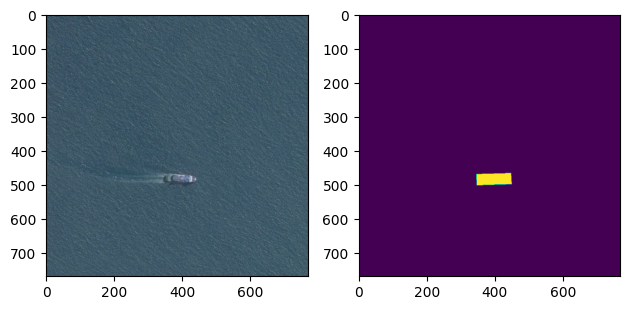

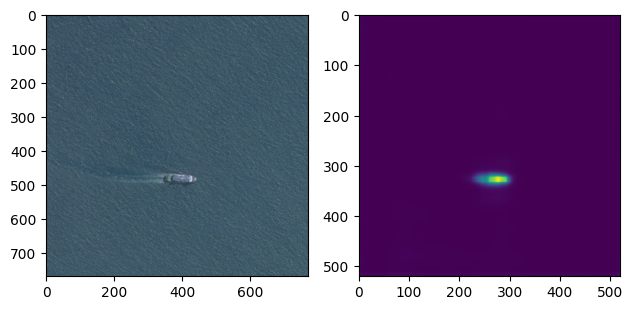

In [8]:
def plot_image_with_mask(df: pd.DataFrame, index: int) -> None:
    fig, ax = plt.subplots(ncols=2)

    img_name = df["ImageId"][index]
    print(img_name)
    img_rle_seqs = df.loc[df["ImageId"] == img_name][
        "EncodedPixels"
    ]  # get rle seqence for each object on the image

    img = cv2.imread(
        os.path.join("./airbus-ship-detection/train_v2", img_name)
    )

    # sum masks of all objects
    img_mask = np.zeros((768, 768), dtype=np.uint8)

    for rle in img_rle_seqs:
        img_mask += rle_decode(rle)

    plt.grid(False)
    ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax[1].imshow(img_mask)
    plt.tight_layout()
    plt.show()

index = 2
plot_image_with_mask(train_segmentations, index)

name = img_name = train_segmentations["ImageId"][index]
image_path = "./airbus-ship-detection/train_v2/"+ name 
img = decode_image(read_file(image_path))
original_image = cv2.imread(image_path)
mask = get_ship_mask(img)
showImages(original_image, mask.detach().numpy())